In [3]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append('segmentation/')

from utils.dnn import DNN

import matplotlib.pyplot as plt
import torch

from utils.model import create_prediction_model, create_model


In [5]:
import zarr

z = zarr.open('data/DynamicNuclearNet-segmentation-v1_0/test.zarr')

In [6]:
X_test = z['X']
y_test = z['y']

print(X_test.shape)

(717, 512, 512, 1)


In [7]:
device = torch.device('cuda:6')

dict_save_path = "data/segmentation/model/saved_model_best_dict.pth"
mdl = create_prediction_model(input_shape=(1,256,256), backbone='efficientnetv2bl', pyramid_levels=("P1","P2", "P3", "P4", "P5", "P6", "P7"), device=device)


mdl.load_state_dict(torch.load(dict_save_path, map_location=device, weights_only=True))

postprocess_kwargs = {
    'radius': 10,
    'interior_index': 1,
    'maxima_threshold': 0.1,
    'exclude_border': False,
    'small_objects_threshold': 0,
    'min_distance': 10,
    'maxima_algorithm': 'peak_local_max'
}

app = DNN(mdl, device, postprocess_kwargs=postprocess_kwargs)


Using ImageNet
Model is using cuda:6
using device: cuda:6


100%|██████████| 1/1 [00:01<00:00,  1.61s/it]


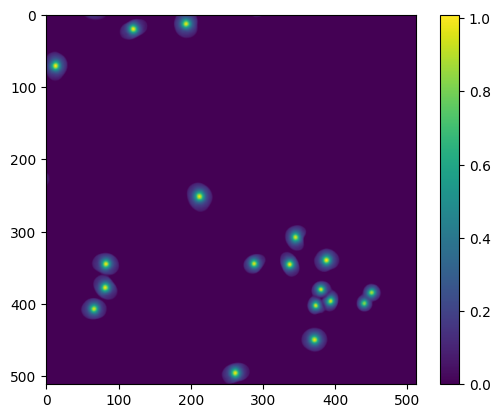

In [8]:
import numpy as np

mask, image = app.predict(X_test[0:1], return_transforms=True)
true_mask = y_test[0:1]

stack = np.concatenate([i for i in image], axis=-1).squeeze()

plt.imshow(stack[...,0].squeeze())
plt.colorbar()

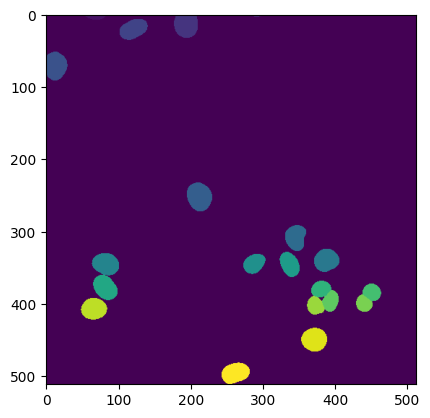

In [20]:
plt.imshow(mask.squeeze())

In [105]:
from skimage.filters import threshold_triangle

threshold = threshold_triangle(stack[...,1].squeeze())

In [112]:
from skimage.measure import label

labeled = label(stack[...,1] >0.01)

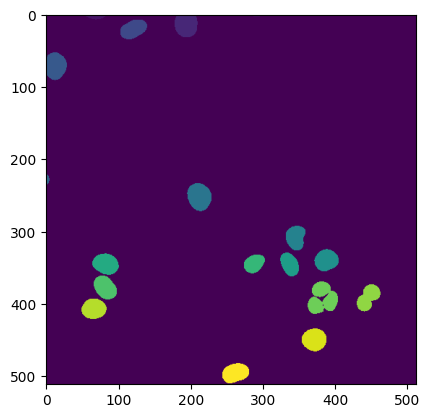

In [113]:
plt.imshow(labeled)